
Random Forest Model Accuracy: 0.8589929297792317
Classification Report for Random Forest:
               precision    recall  f1-score   support

           1       0.47      0.15      0.23     13311
           2       0.90      0.94      0.92   1147311
           3       0.70      0.60      0.65    230005
           4       0.34      0.20      0.25     36344

    accuracy                           0.86   1426971
   macro avg       0.60      0.47      0.51   1426971
weighted avg       0.85      0.86      0.85   1426971


Random Forest ROC-AUC Score: 0.8374794269657683

Logistic Regression Model Accuracy: 0.8040072292989836


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Classification Report for Logistic Regression:
               precision    recall  f1-score   support

           1       0.00      0.00      0.00     13311
           2       0.80      1.00      0.89   1147311
           3       0.19      0.00      0.00    230005
           4       0.00      0.00      0.00     36344

    accuracy                           0.80   1426971
   macro avg       0.25      0.25      0.22   1426971
weighted avg       0.68      0.80      0.72   1426971


Logistic Regression ROC-AUC Score: 0.591042975258194
KNN Accuracy: 0.8165190462875559
Classification Report for KNN:
               precision    recall  f1-score   support

           1       0.23      0.05      0.08     13311
           2       0.86      0.93      0.89   1147311
           3       0.54      0.44      0.48    230005
           4       0.35      0.08      0.13     36344

    accuracy                           0.82   1426971
   macro avg       0.50      0.37      0.40   1426971
weighted avg      

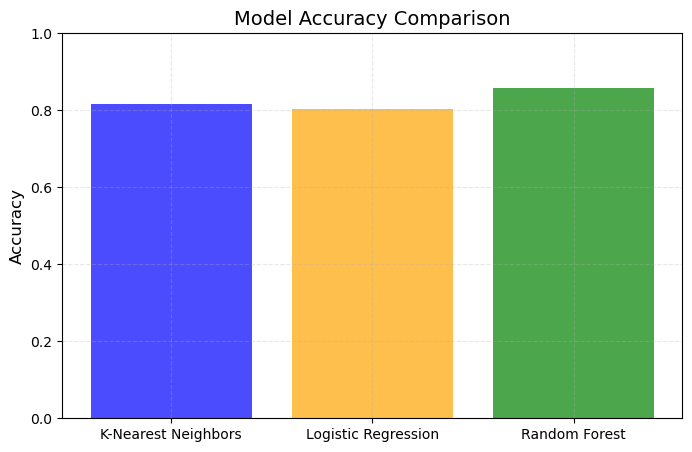

In [6]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import matplotlib.pyplot as plt

# Parameters
file_path = 'US_Accidents_March23.csv'
chunk_size = 100000  # Size of each chunk
columns_to_load = ['Start_Lat', 'Start_Lng', 'Weather_Condition', 'Wind_Speed(mph)', 'Severity']

# Initialize an empty DataFrame to hold filtered data
filtered_data = []

# Load dataset in chunks and filter
for chunk in pd.read_csv(file_path, usecols=columns_to_load, chunksize=chunk_size):
    chunk = chunk.dropna(subset=columns_to_load)  # Drop rows with missing values
    filtered_data.append(chunk)

# Combine filtered chunks into a single DataFrame
filtered_dataset = pd.concat(filtered_data, ignore_index=True)

# Encode Weather_Condition
le = LabelEncoder()
filtered_dataset['Weather_Condition'] = le.fit_transform(filtered_dataset['Weather_Condition'])

# Select relevant features and target variable
X = filtered_dataset[['Start_Lat', 'Start_Lng', 'Weather_Condition', 'Wind_Speed(mph)']]
y = filtered_dataset['Severity']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale numeric features
numeric_selected = ['Start_Lat', 'Start_Lng', 'Wind_Speed(mph)']
scaler = StandardScaler()
X_train[numeric_selected] = scaler.fit_transform(X_train[numeric_selected])
X_test[numeric_selected] = scaler.transform(X_test[numeric_selected])

# Random Forest Model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
rf_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test), multi_class='ovr')
print("\nRandom Forest Model Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification Report for Random Forest:\n", classification_report(y_test, y_pred_rf))
print("\nRandom Forest ROC-AUC Score:", rf_auc)

# Logistic Regression Model
log_reg_model = LogisticRegression(random_state=42, max_iter=1000)
log_reg_model.fit(X_train, y_train)
y_pred_log_reg = log_reg_model.predict(X_test)
log_reg_auc = roc_auc_score(y_test, log_reg_model.predict_proba(X_test), multi_class='ovr')
print("\nLogistic Regression Model Accuracy:", accuracy_score(y_test, y_pred_log_reg))
print("Classification Report for Logistic Regression:\n", classification_report(y_test, y_pred_log_reg))
print("\nLogistic Regression ROC-AUC Score:", log_reg_auc)

# K-Nearest Neighbors Model
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Classification Report for KNN:\n", classification_report(y_test, y_pred_knn))

# New Path Data Prediction
new_path_data = pd.DataFrame({
    'Start_Lat': [34.0522],           # Example latitude of the starting point
    'Start_Lng': [-118.2437],         # Example longitude of the starting point
    'Weather_Condition': ['Clear'],   # Example weather condition
    'Wind_Speed(mph)': [5]            # Example wind speed
})

# Encode and scale new path data
new_path_data['Weather_Condition'] = le.transform(new_path_data['Weather_Condition'])
new_path_data[numeric_selected] = scaler.transform(new_path_data[numeric_selected])

# Predictions for New Path
predicted_severity_rf = rf_model.predict(new_path_data)
predicted_severity_log_reg = log_reg_model.predict(new_path_data)
predicted_severity_knn = knn_model.predict(new_path_data)

print("\nPredicted Severity for New Path using Random Forest:", predicted_severity_rf)
print("Predicted Severity for New Path using Logistic Regression:", predicted_severity_log_reg)
print("Predicted Severity for New Path using KNN:", predicted_severity_knn)

# Visualization: Accuracy Comparison
models = ["K-Nearest Neighbors", "Logistic Regression", "Random Forest"]
accuracy = [
    accuracy_score(y_test, y_pred_knn),
    accuracy_score(y_test, y_pred_log_reg),
    accuracy_score(y_test, y_pred_rf)
]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracy, color=['blue', 'orange', 'green'], alpha=0.7)

plt.title('Model Accuracy Comparison', fontsize=14)
plt.ylabel('Accuracy', fontsize=12)
plt.ylim(0, 1)
plt.grid(alpha=0.3, linestyle='--')
plt.show()
